# OCR — EasyOCR vs Nanonets-OCR-s (meilleure variante)

Démonstration de l'évaluation du moteur OCR des captures Reddit : **EasyOCR** (moteur historique)
vs **Nanonets-OCR-s + nettoyage documentaire + préfixe du titre de thread** (la meilleure variante
Nanonets). On regarde **deux choses** :

1. l'**avant / après du texte océrisé** (nouvel OCR + nettoyage) ;
2. les **scores RAGAS** (5 runs, jeu figé E01–E15) — EasyOCR vs meilleur Nanonets.

> Ce notebook **lit les fichiers de résultats déjà générés** (aucun appel API). Si un fichier manque,
> la cellule l'indique clairement.

In [1]:
# Configuration et helpers (aucun appel API)
import os, glob, json, statistics as st
import pandas as pd
import matplotlib.pyplot as plt

REPO = os.getcwd()
if os.path.basename(REPO) == "notebooks":
    REPO = os.path.dirname(REPO)
RESULTS = os.path.join(REPO, "evaluation", "results")
VAR = os.path.join(RESULTS, "variance_runs")
METRICS = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]

# Les 2 conditions comparées (5 runs chacune) : EasyOCR vs meilleur Nanonets (clean + titre).
CONDITIONS = {
    "EasyOCR": "ragas_routed_llm_sql_only_run[1-9]*_summary.json",
    "Nanonets clean+titre": "ragas_routed_llm_sql_only_nanonets_ocr_clean_title_run*_summary.json",
}

## Avant / après — texte océrisé

Les 4 PDF Reddit sont des **captures d'écran** (0 caractère natif). On compare le texte extrait :
- **Avant** : EasyOCR (moteur historique).
- **Après** : Nanonets-OCR-s + **nettoyage documentaire** (balises HTML, chrome Reddit, pubs, bylines,
  compteurs, flux de posts suggérés ; **tableaux HTML aplatis** en `cellule | cellule`).

D'abord la **quantité** reconnue (caractères/mots par PDF).

moteur,easyocr,nanonets
fichier,,
Reddit 1.pdf,24019,31252
Reddit 2.pdf,38420,67553
Reddit 3.pdf,56553,86505
Reddit 4.pdf,14769,20020


Total caractères : {'easyocr': 133761, 'nanonets': 205330}
Nanonets reconnaît +53.5 % de caractères vs EasyOCR.


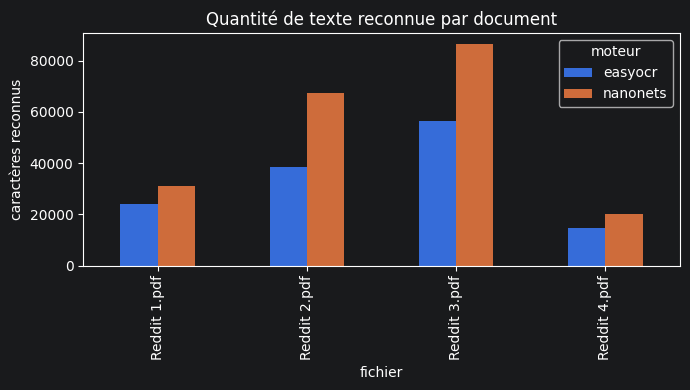

In [2]:
# Quantité reconnue : EasyOCR vs Nanonets (lecture de ocr_recognition_summary.json)
rec_path = os.path.join(RESULTS, "ocr_recognition_summary.json")
if not os.path.exists(rec_path):
    print("Fichier manquant :", rec_path, "-> poetry run python scripts/ocr/compare_recognition.py")
else:
    rec = json.load(open(rec_path, encoding="utf-8"))
    rows = []
    for engine in ("easyocr", "nanonets"):
        for fn, v in (rec.get(engine) or {}).items():
            rows.append({"moteur": engine, "fichier": fn, "caractères": v["chars"]})
    df = pd.DataFrame(rows)
    pivot = df.pivot_table(index="fichier", columns="moteur", values="caractères", aggfunc="sum").sort_index()
    display(pivot)
    tot = df.groupby("moteur")["caractères"].sum()
    print("Total caractères :", tot.to_dict())
    if {"easyocr", "nanonets"} <= set(tot.index):
        print(f"Nanonets reconnaît {(tot['nanonets']-tot['easyocr'])/tot['easyocr']*100:+.1f} % de caractères vs EasyOCR.")
    pivot.plot(kind="bar", figsize=(7, 4)); plt.ylabel("caractères reconnus")
    plt.title("Quantité de texte reconnue par document"); plt.tight_layout(); plt.show()

**Qualité — extrait avant / après** (début de *Reddit 4.pdf*).

*Avant — EasyOCR (bruité)* :
```
12/06/2025 13:12
Which NBA team did not have home court advantage until the NBA Finals?
rInba
Accéder au contenu principal
Se connecter
rInba
ily a 12j
DonT012
```

*Après — Nanonets-OCR-s + nettoyage (post + commentaires lisibles)* :
```
Which NBA team did not have home court advantage until the NBA Finals?
In the NHL, the Edmonton Oilers just reached the NHL Finals. In their 3 rounds of play, they did not
have home court advantage...
Which NBA team experienced this? First 3 rounds all on the road. Finals at home.
Six teams have made the Finals with lower than a 4 seed and none of them have had home court...
Good lord, only 6? I knew it was rare, but I didn't think it was that rare.
```

**Ce que le nettoyage retire** — extrait du *Nanonets brut* (avant nettoyage), supprimé ensuite :
```
<img>r/nba logo</img> r/nba • il y a 12 j DonT012
<img>272 upvotes, 51 comments</img>
adidas_Ecom_Europe • Sponsorisé(e)
Inscris-toi à l'adiClub pour tenter de gagner une carte cadeau de 500 € avec ta Wishlist.
```
Le nettoyage retire : balises `<img>`/`<div>`, chrome Reddit, pubs, bylines « pseudo • -N j », compteurs,
flux de posts suggérés ; et **aplatit les tableaux HTML** en lignes « cellule | cellule ».

## Scores RAGAS — EasyOCR vs meilleur Nanonets (5 runs)

Jeu figé E01–E15, juge `mistral-large`, moyenne ± écart-type sur 5 runs. On distingue le **global**
(15 questions) et la **route RAG** (5 questions documentaires, là où l'OCR agit).

In [3]:
# Chargement des résumés RAGAS (5 runs par condition)
def load_runs(pattern):
    return [json.load(open(p, encoding="utf-8")) for p in sorted(glob.glob(os.path.join(VAR, pattern)))]

def stat(runs, metric, route=None):
    vals = []
    for r in runs:
        sc = (r.get("mean_scores_by_route") or {}).get(route, {}) if route else (r.get("mean_scores") or {})
        if sc.get(metric) is not None:
            vals.append(sc[metric])
    if not vals:
        return (None, None)
    return (st.mean(vals), st.stdev(vals) if len(vals) > 1 else 0.0)

runs = {label: load_runs(pat) for label, pat in CONDITIONS.items()}
runs = {k: v for k, v in runs.items() if v}
for k, v in runs.items():
    print(f"{k}: {len(v)} run(s)")

def table(route=None):
    data = {}
    for label, rr in runs.items():
        col = []
        for m in METRICS:
            mean, sd = stat(rr, m, route)
            col.append(f"{mean:.3f} ± {sd:.3f}" if mean is not None else "—")
        data[label] = col
    return pd.DataFrame(data, index=METRICS)

print("\n=== GLOBAL (15 questions) ==="); display(table())
print("=== Route RAG (5 questions documentaires) ==="); display(table("rag"))

EasyOCR: 5 run(s)
Nanonets clean+titre: 5 run(s)

=== GLOBAL (15 questions) ===


,EasyOCR,Nanonets clean+titre
faithfulness,0.539 ± 0.017,0.544 ± 0.017
answer_relevancy,0.604 ± 0.049,0.619 ± 0.025
context_precision,0.552 ± 0.038,0.563 ± 0.018
context_recall,0.618 ± 0.028,0.556 ± 0.041


=== Route RAG (5 questions documentaires) ===


,EasyOCR,Nanonets clean+titre
faithfulness,0.441 ± 0.020,0.497 ± 0.013
answer_relevancy,0.691 ± 0.151,0.743 ± 0.067
context_precision,0.455 ± 0.113,0.490 ± 0.055
context_recall,0.800 ± 0.071,0.733 ± 0.122


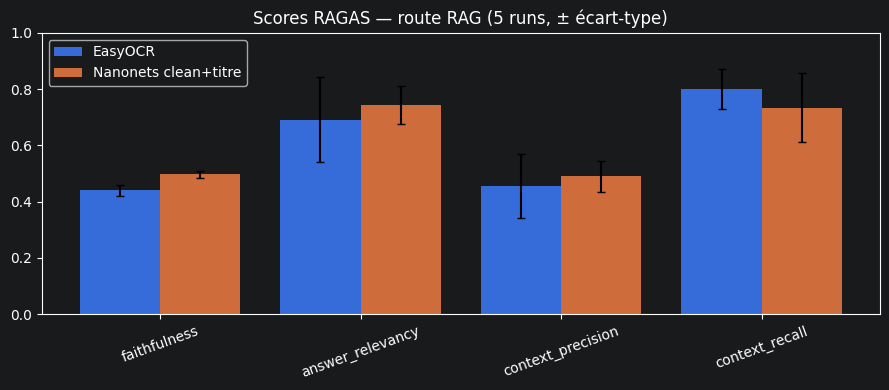

In [4]:
# Graphique : EasyOCR vs meilleur Nanonets (route RAG, ± écart-type)
labels = list(runs.keys())
x = range(len(METRICS)); width = 0.8 / max(len(labels), 1)
fig, ax = plt.subplots(figsize=(9, 4))
for i, label in enumerate(labels):
    means = [stat(runs[label], m, "rag")[0] or 0 for m in METRICS]
    errs = [stat(runs[label], m, "rag")[1] or 0 for m in METRICS]
    ax.bar([xi + i * width for xi in x], means, width, yerr=errs, capsize=3, label=label)
ax.set_xticks([xi + width * (len(labels) - 1) / 2 for xi in x])
ax.set_xticklabels(METRICS, rotation=20); ax.set_ylim(0, 1)
ax.set_title("Scores RAGAS — route RAG (5 runs, ± écart-type)"); ax.legend()
plt.tight_layout(); plt.show()

## Conclusion

- **OCR brute** : Nanonets reconnaît plus de texte (+53 %) et plus proprement qu'EasyOCR (cf. §1).
- **RAGAS** : ce gain brut **ne suffit pas** ; il faut un **nettoyage documentaire** + un **préfixe du
  titre de thread** pour revenir autour de la **parité** avec EasyOCR sur E01–E15.
- **Configuration recommandée** : *si Nanonets est activé, la configuration recommandée est
  Nanonets-OCR-s avec nettoyage documentaire et préfixe du titre de thread. Cette variante améliore la
  fidélité et récupère une partie du rappel perdu par le nettoyage strict, mais elle ne justifie pas une
  activation par défaut.*
- **Décision** : agrégat global ≈ parité (`context_recall` reste sous EasyOCR), modèle lourd (~7 Go) →
  **EasyOCR reste le moteur par défaut**, Nanonets reste **optionnel**.

> Comparaison complète (5 conditions) et détails : `evaluation/results/nanonets_ocr_analysis.md`.